In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn import svm
from sklearn.metrics import accuracy_score

In [9]:
df_train = pd.read_csv("Datasets/Training.csv")
df_test = pd.read_csv("Datasets/Testing.csv")

In [10]:
df = pd.concat([df_train, df_test], ignore_index=True)
df

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
...,...,...,...,...,...,...,...,...,...
2763,10,101,76,48,180,32.9,0.171,63,0
2764,2,122,70,27,0,36.8,0.340,27,0
2765,5,121,72,23,112,26.2,0.245,30,0
2766,1,126,60,0,0,30.1,0.349,47,1


In [11]:
print(df_train.shape, df_test.shape)

(2460, 9) (308, 9)


In [12]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,2768.000000,2768.000000,2768.000000,2768.000000,2768.000000,2768.00000,2768.000000,2768.000000,2768.000000
mean,3.822616,121.421965,68.980491,20.549494,79.853324,31.97659,0.486277,32.923049,0.380419
std,3.305432,31.721258,19.133100,15.779713,115.655771,7.76054,0.357403,11.362964,0.485578
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.078000,21.000000,0.000000
25%,1.000000,100.000000,64.000000,0.000000,0.000000,27.17500,0.248000,24.000000,0.000000
50%,3.000000,117.000000,71.000000,23.000000,36.000000,32.10000,0.380000,29.000000,0.000000
75%,6.000000,142.000000,80.000000,33.000000,129.000000,36.50000,0.645250,40.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.10000,2.420000,81.000000,1.000000


In [13]:
df['Outcome'].value_counts()
# 0=non-diabetic, 1=diabetic

Outcome
0    1715
1    1053
Name: count, dtype: int64

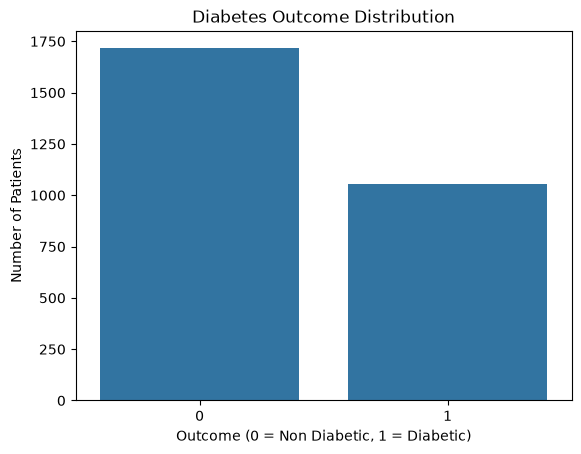

In [14]:
sns.countplot(data=df, x="Outcome")

plt.title("Diabetes Outcome Distribution")
plt.xlabel("Outcome (0 = Non Diabetic, 1 = Diabetic)")
plt.ylabel("Number of Patients")
plt.show()

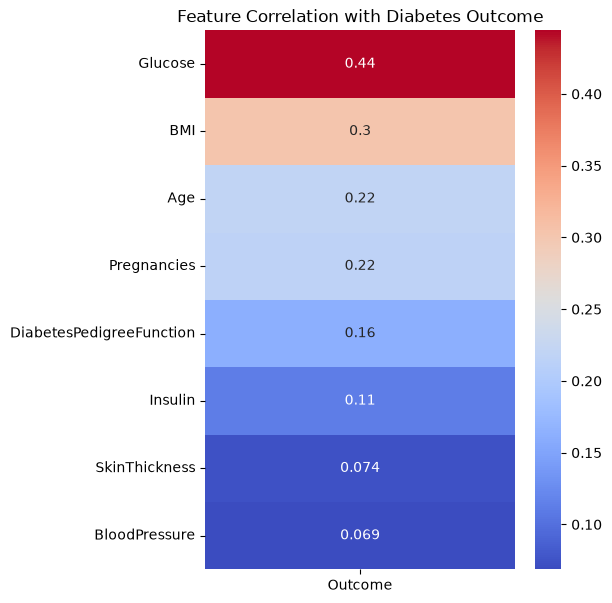

In [15]:
correlation = df.corr()[["Outcome"]].drop("Outcome")
correlation = correlation.sort_values("Outcome", ascending=False)

plt.figure(figsize=(5, 7))
sns.heatmap(correlation, annot=True, cmap="coolwarm")

plt.title("Feature Correlation with Diabetes Outcome")
plt.show()

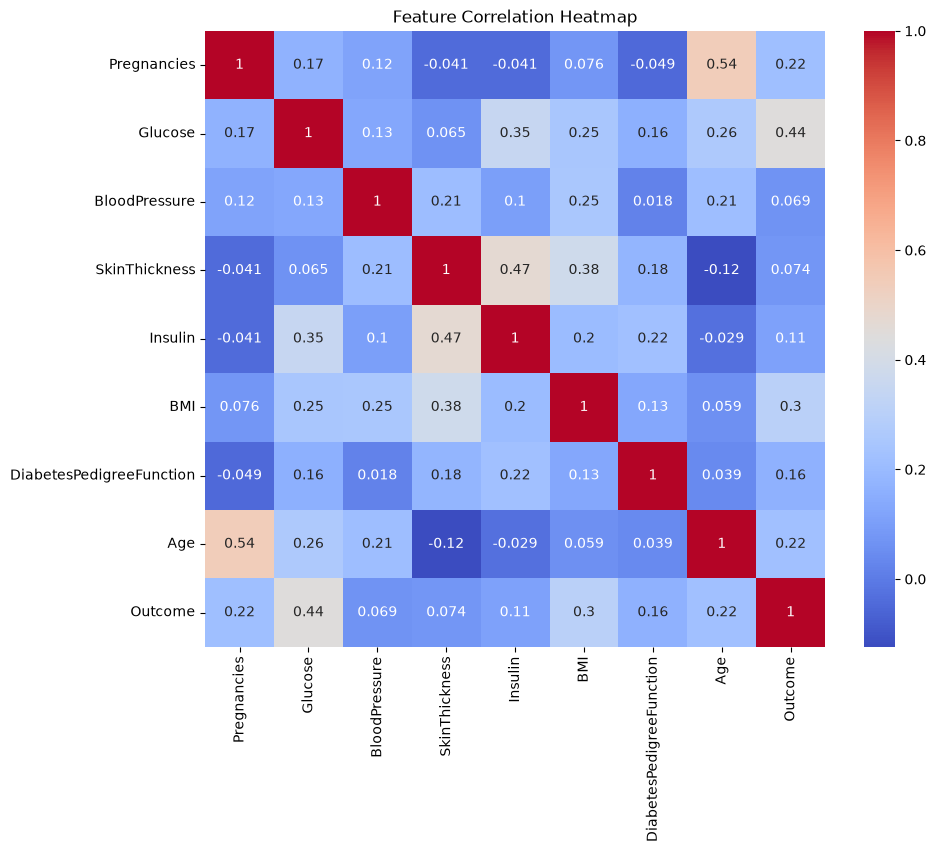

In [16]:
plt.figure(figsize=(10, 8))

sns.heatmap(
    df.corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Feature Correlation Heatmap")
plt.show()

In [17]:
df.groupby('Outcome').mean()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
Outcome,,,,,,,,
0,3.262391,110.381341,67.951603,19.634985,69.715452,30.13691,0.440986,30.960933
1,4.735043,139.403609,70.656220,22.038936,96.364672,34.97284,0.560042,36.118708


In [18]:
x = df.drop(columns='Outcome')
y = df['Outcome']
print(x, y)

      Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0               6      148             72             35        0  33.6   
1               1       85             66             29        0  26.6   
2               8      183             64              0        0  23.3   
3               1       89             66             23       94  28.1   
4               0      137             40             35      168  43.1   
...           ...      ...            ...            ...      ...   ...   
2763           10      101             76             48      180  32.9   
2764            2      122             70             27        0  36.8   
2765            5      121             72             23      112  26.2   
2766            1      126             60              0        0  30.1   
2767            1       93             70             31        0  30.4   

      DiabetesPedigreeFunction  Age  
0                        0.627   50  
1                      

### Train Test Split

In [19]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.2, stratify=y, random_state = 2)

In [20]:
print(x.shape, x_train.shape, x_test.shape)

(2768, 8) (2214, 8) (554, 8)


### Data Standardization

In [21]:
scaler = StandardScaler()

In [22]:
scaler.fit_transform(x_train)

array([[ 0.36019947,  1.40931263,  0.36101958, ...,  1.77559974,
        -0.41082148, -0.52278897],
       [-1.16287467, -0.63993644,  0.36101958, ...,  0.48433083,
        -0.81319836, -0.60994015],
       [ 2.79711809,  0.242817  , -3.60080121, ...,  1.02666377,
         0.23808207,  0.95878104],
       ...,
       [-0.85825985, -0.98673244, -0.05601419, ..., -0.96189036,
         1.85042322,  0.26157162],
       [-0.85825985,  0.68419373,  0.25676114, ..., -0.74237465,
        -0.64884724, -1.04569603],
       [ 1.88327361,  0.02212864, -0.05601419, ..., -0.09674019,
        -0.64317996,  0.69732751]], shape=(2214, 8))

In [23]:
standard_data = scaler.transform(x_test)

In [24]:
standard_data

array([[ 1.57865878, -0.60840953,  0.36101958, ...,  0.12277553,
         0.51011151,  1.13308339],
       [-0.85825985,  0.77877445, -0.68156484, ..., -0.29043053,
         0.22391387, -0.34848662],
       [-0.85825985,  0.936409  , -0.47304796, ..., -0.75528734,
        -0.86703752, -0.95854486],
       ...,
       [-1.16287467, -0.60840953, -0.26453107, ...,  1.1170526 ,
         0.03122635, -1.04569603],
       [ 0.66481429, -0.32466735, -0.26453107, ...,  0.29064049,
        -0.63751268, -0.7842425 ],
       [ 1.57865878,  0.05365555,  0.04824425, ...,  0.14860091,
        -0.31447772,  0.61017633]], shape=(554, 8))

### Training the Model

In [25]:
classifier = svm.SVC(kernel = 'rbf', C= 1, gamma = 1)

In [26]:
classifier.fit(x_train, y_train)

,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",1
,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide <shrinking_svm>`.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide <scores_probabilities>`...deprecated:: 1.9 The `probability` parameter is deprecated and will be removed in 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`.",'deprecated'
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


### Model Evaluation

In [29]:
x_train_predict = classifier.predict(x_train)
training_accuracy = accuracy_score(x_train_predict, y_train)
print(f"Accuracy on training data: {training_accuracy*100} %")

x_test_predict = classifier.predict(x_test)
test_accuracy = accuracy_score(x_test_predict, y_test)
print(f"Accuracy on test data: {test_accuracy*100} %")

Accuracy on training data: 100.0 %
Accuracy on test data: 97.11191335740072 %


In [ ]:
#x_final_prediction = classifier.predict(standard_data)

c:\Python\Lib\site-packages\sklearn\utils\validation.py:2830: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(


In [ ]:
'''
def predict_model():
    preg = int(input("No. of pregnancies: "))
    glucose = float(input("Glucose Level: "))
    bp = float(input("Blood Pressure: "))
    skin = float(input("Skin Thickness: "))
    insulin = float(input("Insulin Level: "))
    bmi = float(input("BMI: "))
    dpf = float(input("Diabetes Pedigree Function: "))
    age = float(input("Age: "))

    new_data = pd.DataFrame([[
    preg, glucose, bp, skin, insulin, bmi, dpf, age]], columns=x.columns)

    new_data = scaler.transform(new_data)

    result = classifier.predict(new_data)
    if result[0] == 1:
        print("Patient is Diabetic")
    else:
        print("Patient is Not Diabetic")
'''

In [24]:
#predict_model()